# L2 —— 免疫谱系 粗分类
 目标：在 L1 的 Immune 子集中，进行“粗粒度”二级注释，仅识别主要五类免疫细胞（T、B、Plasma、NK、Myeloid），未达标者统一标为 Other，后续再细化

 ## 产出：
 - obs：L2_marker, L2_marker_gap, L2_score, L2_score_gap, L2_gpt_raw, L2_gpt, L2_celltype_sub, L2_conf_methods, L2_stability, L2_conf, L2_votes, L2_celltype

- 审阅表：L2_immune_summary.csv（obs）

- 对象：L2_immune_annotated.h5ad（并把标签写回全集对象）

## 环境与路径

In [2]:
# Code cell
import os, re
import numpy as np
import pandas as pd
import scanpy as sc
import scanpy.external as sce
from scipy.sparse import issparse
import matplotlib.pyplot as plt
import omicverse as ov

# 路径与文件
DATA_ROOT = "/mnt/c/Users/Future/Nutstore/1/UC/scRNA-seq_data"
ANNO_DIR  = os.path.join(DATA_ROOT, "06_annotation"); os.makedirs(ANNO_DIR, exist_ok=True)
FIG_DIR   = os.path.join(ANNO_DIR, "figs");          os.makedirs(FIG_DIR,  exist_ok=True)

IN_PATH   = os.path.join(ANNO_DIR, "L1/L1_lineage_annotated_slim.h5ad")  # 或非 slim
OUT_H5AD  = os.path.join(ANNO_DIR, "L2/01_L2_immune_annotated.h5ad")
OUT_CSV   = os.path.join(ANNO_DIR, "L2/01_L2_immune_summary.csv")

# 键位与参数（与 L1 风格同构）
BATCH_KEY   = "GSM"          # 批次键：GSM 或 GSE
RES_LIST    = [0.2, 0.4, 0.6]# 低分辨率（粗分类不需要太高）
MAIN_RES    = 0.4            # 主分辨率用于定标签
LOW_TH      = 2/3            # 低置信度回收阈 至少两票一致才通过
STAB_WEIGHT = 0.2            # 稳定度权重（粗分类→权重低）
LINEAGE_PREFIX = "Immune|"

# 读入 & 子集
adata = sc.read_h5ad(IN_PATH)
sub = adata[adata.obs["L1_lineage"]=="Immune"].copy()
print(sub)

# 若有原始计数，先切回 counts 再开始标准流程
if "counts" in sub.layers:
    sub.X = sub.layers["counts"]


AnnData object with n_obs × n_vars = 187365 × 3000
    obs: 'leiden_scVI_0.2', 'GSM', 'GSE', 'group', '_scvi_batch', 'L1lin_marker', 'L1lin_score', 'L1lin_gpt', 'L1_lineage', 'L1lin_conf', 'L1lin_votes'
    var: 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'GSE_colors', 'L1_lineage_colors', 'REFERENCE_MANU', '_scvi_manager_uuid', '_scvi_uuid', 'hvg', 'leiden_scVI_0.2', 'leiden_scVI_0.2_colors', 'neighbors', 'umap'
    obsm: 'X_scVI', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities'


## HVG → PCA → Harmony → neighbors → leiden

In [3]:
sc.pp.normalize_total(sub, target_sum=1e4)
sc.pp.log1p(sub)

In [4]:
# 标记 HVG，但不裁剪基因
sc.pp.highly_variable_genes(
    sub, n_top_genes=3000, flavor="seurat_v3",
    subset=False, span=0.5, check_values=False
)
hv_mask = sub.var["highly_variable"].values

In [5]:
# 仅在 HVG 上做 PCA（不丢非HVG；把结果写回到 sub）
sub_hv = sub[:, hv_mask].copy()
sc.pp.scale(sub_hv, max_value=10)
sc.tl.pca(sub_hv, n_comps=50, svd_solver="arpack")
sub.obsm["X_pca"] = sub_hv.obsm["X_pca"]
sub.varm["PCs"]   = sub_hv.varm["PCs"]

In [6]:
# Harmony 去批次（基于 PCA）
sce.pp.harmony_integrate(sub, key=BATCH_KEY, basis="X_pca")
sub

2025-11-12 17:04:03,419 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-11-12 17:04:17,040 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-11-12 17:04:17,929 - harmonypy - INFO - Iteration 1 of 10
2025-11-12 17:05:59,988 - harmonypy - INFO - Iteration 2 of 10
2025-11-12 17:07:41,304 - harmonypy - INFO - Iteration 3 of 10
2025-11-12 17:09:23,066 - harmonypy - INFO - Iteration 4 of 10
2025-11-12 17:11:08,177 - harmonypy - INFO - Iteration 5 of 10
2025-11-12 17:12:47,075 - harmonypy - INFO - Iteration 6 of 10
2025-11-12 17:14:27,076 - harmonypy - INFO - Iteration 7 of 10
2025-11-12 17:16:06,065 - harmonypy - INFO - Iteration 8 of 10
2025-11-12 17:17:21,528 - harmonypy - INFO - Iteration 9 of 10
2025-11-12 17:18:36,308 - harmonypy - INFO - Iteration 10 of 10
2025-11-12 17:19:41,690 - harmonypy - INFO - Stopped before convergence


AnnData object with n_obs × n_vars = 187365 × 3000
    obs: 'leiden_scVI_0.2', 'GSM', 'GSE', 'group', '_scvi_batch', 'L1lin_marker', 'L1lin_score', 'L1lin_gpt', 'L1_lineage', 'L1lin_conf', 'L1lin_votes'
    var: 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'GSE_colors', 'L1_lineage_colors', 'REFERENCE_MANU', '_scvi_manager_uuid', '_scvi_uuid', 'hvg', 'leiden_scVI_0.2', 'leiden_scVI_0.2_colors', 'neighbors', 'umap', 'log1p'
    obsm: 'X_scVI', 'X_umap', 'X_pca', 'X_pca_harmony'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities'

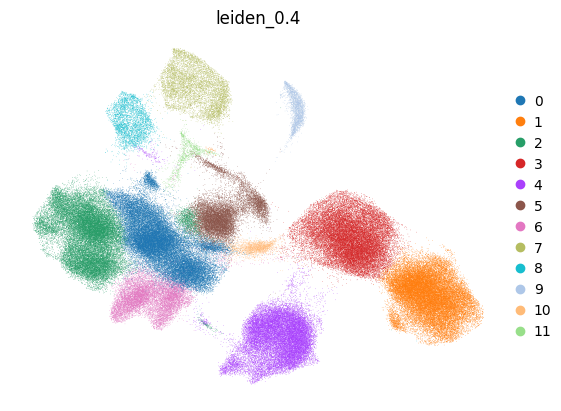

In [7]:
# 邻域/聚类/UMAP
sc.pp.neighbors(sub, use_rep="X_pca_harmony", n_neighbors=20)
for r in RES_LIST:
    sc.tl.leiden(sub, resolution=r, key_added=f"leiden_{r}")
sc.tl.umap(sub)

sc.pl.umap(sub, color=[f"leiden_{MAIN_RES}"], frameon=False)

## 粗分类面板
保留区分力最强、跨数据集最稳定的标记，宁缺毋滥。

In [8]:
# 粗分类面板（L2：Immune 粗粒度；T 与 NK 合并为 T_NK）
coarse_panels = {
    # T + NK 合并（L2只要粗分，L3再拆 CD4/CD8、NK等）
    "T_NK": [
        # T 基础
        "PTPRC","CD3D","CD3E","CD2","TRAC","IL7R","CD4","CD8A","CD8B",
        # NK 特征
        "NCR1","KLRD1","NKG7","GNLY","PRF1","GZMB","GZMH","KLRK1","FGFBP2","TYROBP"
    ],
    "B": [
        "MS4A1","CD79A","CD79B","CD74","BANK1","CD19","CD37"
    ],
    "Plasma": [
        "JCHAIN","MZB1","XBP1","IGHG1","IGKC","IGLC2","SDC1"
    ],
    # Myeloid
    "Myeloid": [
        # 泛髓系 / 单核
        "LYZ","LST1","S100A8","S100A9","FCGR3A","VCAN","FCN1","CTSS","ITGAM","ITGAX"
    ]
}

# 只保留对象存在的基因
coarse_panels = {k:[g for g in v if g in sub.var_names] for k,v in coarse_panels.items()}

In [9]:
# Gene-set 打分（在 log1p 矩阵上）
for name, genes in coarse_panels.items():
    if genes:
        sc.tl.score_genes(sub, gene_list=genes, score_name=f"L2score_{name}", use_raw=False)

# 为 GPT 准备 rank_genes（主分辨率）
sc.tl.rank_genes_groups(sub, groupby=f"leiden_{MAIN_RES}", method="wilcoxon")


## 方法A：Marker 直读（簇均值 × 阳性占比）

In [10]:
# Code cell
def _toarray(X): return X.toarray() if issparse(X) else X
def _pct_expr(adata, genes, mask):
    if not genes: return 0.0
    X=_toarray(adata[mask, genes].X); return float((X>0).mean())
def _mean_expr(adata, genes, mask):
    if not genes: return 0.0
    X=_toarray(adata[mask, genes].X); return float(X.mean())

main_key = f"leiden_{MAIN_RES}"
cats = list(sub.obs[main_key].cat.categories)

marker_call, marker_gap = {}, {}
for cl in cats:
    msk = (sub.obs[main_key]==cl).values
    scores={}
    for lab, genes in coarse_panels.items():
        m=_mean_expr(sub, genes, msk); p=_pct_expr(sub, genes, msk) 
        scores[lab]=0.6*m+0.4*p # 加权评分
    s = pd.Series(scores).sort_values(ascending=False).iloc[:2] # 前两名
    marker_call[cl] = s.index[0] if len(s)>0 else "Other" 
    marker_gap[cl]  = float(s.iloc[0]-s.iloc[1]) if len(s)==2 else (float(s.iloc[0]) if len(s)==1 else 0.0) # 差值


In [11]:
# —— 单方法预过滤（Marker）：用 gap 的分位数做阈值，把低于阈值的簇置为 Other ——
GAP_Q_MARKER = 0.20  # 建议 20% 分位（更保守可调到 0.25）
_marker_gaps = np.array([marker_gap.get(cl, np.nan) for cl in cats], dtype=float)
_marker_gaps = _marker_gaps[np.isfinite(_marker_gaps)]
if _marker_gaps.size > 0:
    MARKER_GAP_TH = float(np.quantile(_marker_gaps, GAP_Q_MARKER))
    # 可选：避免阈值过低，给一个地板
    MARKER_GAP_TH = max(MARKER_GAP_TH, 0.0)

    n_mark_other = 0
    for cl in cats:
        if marker_gap.get(cl, -np.inf) < MARKER_GAP_TH:
            marker_call[cl] = "Other"; n_mark_other += 1
    print(f"[Marker filter] gap@{int(GAP_Q_MARKER*100)}% = {MARKER_GAP_TH:.4g}; "
          f"relabelled {n_mark_other} clusters → Other")


[Marker filter] gap@20% = 0.1686; relabelled 3 clusters → Other


In [12]:
sub.obs["L2_marker"]      = sub.obs[main_key].map(marker_call).astype("category")
sub.obs["L2_marker_gap"]  = sub.obs[main_key].map(marker_gap).astype(float)

In [13]:
# === 展示方法A: Marker直读 ===
marker_df = pd.DataFrame({
    "cluster": cats,
    "n_cells": [int((sub.obs[main_key]==cl).sum()) for cl in cats],
    "method":  ["marker"]*len(cats),
    "label":   [marker_call[cl] for cl in cats],
    "conf_gap":[marker_gap[cl]  for cl in cats]
}).sort_values(["label","cluster"])
display(marker_df)

,cluster,n_cells,method,label,conf_gap
4,4,23516,marker,B,1.240580
7,7,7148,marker,Myeloid,0.315793
10,10,1948,marker,Other,0.116475
5,5,13292,marker,Other,0.039326
6,6,11677,marker,Other,0.148681
1,1,31164,marker,Plasma,1.320163
11,11,1138,marker,Plasma,0.656918
3,3,26017,marker,Plasma,1.489562
8,8,3737,marker,Plasma,0.444944
9,9,2520,marker,Plasma,0.316655


## 方法B：Gene-set 打分（簇均值）

In [14]:
# Code cell
score_call, score_gap = {}, {}
for cl in cats:
    msk = (sub.obs[main_key]==cl).values
    vals = {lab: sub.obs.loc[msk, f"L2score_{lab}"].mean() if f"L2score_{lab}" in sub.obs else -1e9
            for lab in coarse_panels}
    s = pd.Series(vals).sort_values(ascending=False).iloc[:2]
    score_call[cl] = s.index[0] if len(s)>0 else "Other"
    score_gap[cl]  = float(s.iloc[0]-s.iloc[1]) if len(s)==2 else (float(s.iloc[0]) if len(s)==1 else 0.0)


In [15]:
# —— 单方法预过滤（Score）：用 gap 的分位数做阈值，把低于阈值的簇置为 Other ——
GAP_Q_SCORE = 0.20  # 建议与 Marker 一致
_score_gaps = np.array([score_gap.get(cl, np.nan) for cl in cats], dtype=float)
_score_gaps = _score_gaps[np.isfinite(_score_gaps)]
if _score_gaps.size > 0:
    SCORE_GAP_TH = float(np.quantile(_score_gaps, GAP_Q_SCORE))
    SCORE_GAP_TH = max(SCORE_GAP_TH, 0.0)

    n_score_other = 0
    for cl in cats:
        if score_gap.get(cl, -np.inf) < SCORE_GAP_TH:
            score_call[cl] = "Other"; n_score_other += 1
    print(f"[Score filter] gap@{int(GAP_Q_SCORE*100)}% = {SCORE_GAP_TH:.4g}; "
          f"relabelled {n_score_other} clusters → Other")


[Score filter] gap@20% = 0.2237; relabelled 3 clusters → Other


In [16]:
sub.obs["L2_score"]     = sub.obs[main_key].map(score_call).astype("category")
sub.obs["L2_score_gap"] = sub.obs[main_key].map(score_gap).astype(float)


In [17]:
# === 展示方法B: Gene-set打分 ===
score_df = pd.DataFrame({
    "cluster": cats,
    "n_cells": [int((sub.obs[main_key]==cl).sum()) for cl in cats],
    "method":  ["score"]*len(cats),
    "label":   [score_call[cl] for cl in cats],
    "conf_gap":[score_gap[cl]  for cl in cats]
}).sort_values(["label","cluster"])
display(score_df)

,cluster,n_cells,method,label,conf_gap
4,4,23516,score,B,1.789123
7,7,7148,score,Myeloid,1.244694
10,10,1948,score,Other,0.161287
5,5,13292,score,Other,0.159203
9,9,2520,score,Other,0.179906
1,1,31164,score,Plasma,1.660215
11,11,1138,score,Plasma,0.582671
3,3,26017,score,Plasma,2.024674
8,8,3737,score,Plasma,0.398849
0,0,34375,score,T_NK,0.436757


## 方法C：GPT

In [18]:
# 1) 确保按主分辨率做了差异分析（DE）
cluster_key = main_key  # 例如 "leiden_0.5"
if ('rank_genes_groups' not in sub.uns or
    sub.uns['rank_genes_groups'].get('params', {}).get('groupby') != cluster_key):
    sc.tl.rank_genes_groups(
        sub,
        groupby=cluster_key,
        method='wilcoxon',   # 稳健、常用
        n_genes=300,         # 先算足量，后面再截取 topN
        use_raw=False
    )

# 2) 从 rg['names'] 提取每簇 TopN 基因 → all_markers: {cluster: [gene1,...,geneN]}
topN = 10
rg = sub.uns['rank_genes_groups']
names = rg['names']                       # 结构化数组，每列对应一个簇
groups = names.dtype.names                # 簇名列表（字符串）

all_markers = {
    g: [str(x) for x in names[g][:topN] if str(x) in sub.var_names]
    for g in groups
}

# 3) 快速查看与体检：预览若干簇的 marker；标出为空的簇
print(f"[markers] clusters={len(all_markers)}, topN={topN}")
for i, (g, glist) in enumerate(all_markers.items()):
    print(f"  - {g}: {len(glist)} genes -> {glist[:5]}{'...' if len(glist)>5 else ''}")
    if i >= 6:  # 预览前 7 个簇即可
        break

empty_clusters = [g for g, gl in all_markers.items() if len(gl) == 0]
print("[markers] empty clusters:", empty_clusters)

[markers] clusters=12, topN=10
  - 0: 10 genes -> ['IL7R', 'ANXA1', 'CD3E', 'TNFAIP3', 'S100A4']...
  - 1: 10 genes -> ['MZB1', 'SSR4', 'DERL3', 'SEC11C', 'FKBP11']...
  - 2: 10 genes -> ['CCL5', 'NKG7', 'GZMA', 'CST7', 'IL32']...
  - 3: 10 genes -> ['IGKC', 'IGHA1', 'MZB1', 'SSR4', 'DERL3']...
  - 4: 10 genes -> ['CD74', 'MS4A1', 'CD83', 'CD37', 'CD79A']...
  - 5: 10 genes -> ['RPL32', 'RPS3A', 'RPS15A', 'RPS12', 'RPL34']...
  - 6: 10 genes -> ['CD3D', 'SRGN', 'IL32', 'SPOCK2', 'TIGIT']...
[markers] empty clusters: []


In [19]:
# GPT 识别（保持与 L1 一样的调用；密钥自行在外部环境配置）
# 例：export AGI_API_KEY=xxxx
os.environ['AGI_API_KEY'] = 'sk-b54d8fd2ec144ce78b32602024fba248'
gpt_raw = ov.single.gptcelltype(
    all_markers, tissuename='immune cells', speciename='human',
    model='qwen-plus', provider='qwen', topgenenumber=10
)  # dict: {cluster -> free-text}
gpt_raw

Note: AGI API key found: returning the cell type annotations.
Note: It is always recommended to check the results returned by GPT-4 in case of AI hallucination, before going to downstream analysis.


{'0': 'T cell',
 '1': 'Plasma cell',
 '2': 'Cytotoxic T cell or NK cell',
 '3': 'Plasma cell',
 '4': 'B cell',
 '5': 'Ribosomal protein-expressing cell (non-immune)',
 '6': 'T cell',
 '7': 'Myeloid cell',
 '8': 'Proliferating cell',
 '9': 'Monocyte or macrophage',
 '10': 'Activated immune cell',
 '11': 'Fibroblast or stromal cell'}

In [20]:
SYNS_IMMUNE_COARSE = {
    "T_NK": [
        # T 系
        "t cell","t-cell","cd3","trac","cd2","il7r","cd4","cd8","treg","foxp3","il2ra",
        # NK 系
        "nk","nk cell","ncr1","klrc1","klrd1","nkg7","gnly","prf1","gzmb","gzmh","fgfbp2","tyrobp"
    ],
    "B": [
        "b cell","b-cell","ms4a1","cd79","bank1","cd74","cd19"
    ],
    "Plasma": [
        "plasma","plasmablast","jchain","mzb1","xbp1","igh","igkc","iglc","sdc1"
    ],
    "Myeloid": [
        "myeloid","monocyte","macrophage","mo","mφ","dendritic","dc","cDC1","cDC2","pdc",
        "clec9a","xcr1","batf3","cd1c","clec10a","fcer1a",
        "lyz","lst1","s100a8","s100a9","fcn1","vcan","fcgr3a","ctss","itgam","itgax",
        "c1qa","c1qb","c1qc","apoe","apoc1","msr1","cd68","cd163","mrc1","marco","lipa",
        "il1b","nlrp3","s100a12","cxcl8","tnf",
        "neutrophil","granulocyte","mpo","elane","fcgr3b","cxcr2"
    ]
}

In [21]:
import re
def _norm(s):
    s = (s or "").lower()
    s = re.sub(r"[^a-z0-9\s]", " ", s)
    s = re.sub(r"\s+"," ", s).strip()
    return s

def map_gpt_coarse(label: str) -> str:
    t = _norm(label)
    for lab, keys in SYNS_IMMUNE_COARSE.items():
        if any(k in t for k in keys):
            return lab
    return "Other"

# 将 GPT 自由文本映射为受控标签
cats = list(sub.obs[cluster_key].cat.categories)
gpt_std_map = {cl: map_gpt_coarse(gpt_raw.get(cl, "")) for cl in cats}

# 写回 obs（与 L1 同名风格）
sub.obs["L2_gpt_raw"] = sub.obs[cluster_key].map(gpt_raw).astype("category")
sub.obs["L2_gpt"]     = sub.obs[cluster_key].map(gpt_std_map).astype("category")

In [22]:
# === 展示方法C: GPT自由文本映射 ===
gpt_df = pd.DataFrame({
    "cluster": cats,
    "n_cells": [int((sub.obs[main_key]==cl).sum()) for cl in cats],
    "method":  ["gpt"]*len(cats),
    "label":   [gpt_std_map[cl] for cl in cats],
    "conf_gap":[np.nan]*len(cats)
}).sort_values(["label","cluster"])
display(gpt_df)

,cluster,n_cells,method,label,conf_gap
4,4,23516,gpt,B,NaN
7,7,7148,gpt,Myeloid,NaN
9,9,2520,gpt,Myeloid,NaN
10,10,1948,gpt,Other,NaN
11,11,1138,gpt,Other,NaN
5,5,13292,gpt,Other,NaN
8,8,3737,gpt,Other,NaN
1,1,31164,gpt,Plasma,NaN
3,3,26017,gpt,Plasma,NaN
0,0,34375,gpt,T_NK,NaN


## 和票 + 低置信度回收

目的：综合三种注释方法（Marker、Gene-set 打分、GPT 注释）的结果，为每个簇确定一个最可信的标签，并量化它的可靠程度。

做法：
1. 每个簇分别从三种方法中取出标签。

2. 去掉无效或兜底结果（如 Other 或 None）。

3. 统计各标签出现次数：出现次数最多的作为最终标签。

4. 方法一致性置信度 = 最高票数 ÷ 有效票总数。例：三票一致 → 1.0；两票对一票 → 0.67。

5. 如果一致性置信度 < 设定阈值 (LOW_TH, 如 0.6)，则说明方法间分歧较大，暂时回收为 Other。

意义：

- 多数决让三条证据链互相校正，降低单一方法出错的风险。

- 置信度数值反映“方法间一致程度”；越高说明结果越可靠。

- 低置信度回收保持分析保守，避免误标细胞类型。

最终结果：

- L2_celltype_sub：簇的最终子类标签

- L2_conf_methods：方法一致性置信度

- L2_celltype：带谱系前缀的层级标签（如 Immune|T）

In [23]:
sub

AnnData object with n_obs × n_vars = 187365 × 3000
    obs: 'leiden_scVI_0.2', 'GSM', 'GSE', 'group', '_scvi_batch', 'L1lin_marker', 'L1lin_score', 'L1lin_gpt', 'L1_lineage', 'L1lin_conf', 'L1lin_votes', 'leiden_0.2', 'leiden_0.4', 'leiden_0.6', 'L2score_T_NK', 'L2score_B', 'L2score_Plasma', 'L2score_Myeloid', 'L2_marker', 'L2_marker_gap', 'L2_score', 'L2_score_gap', 'L2_gpt_raw', 'L2_gpt'
    var: 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'GSE_colors', 'L1_lineage_colors', 'REFERENCE_MANU', '_scvi_manager_uuid', '_scvi_uuid', 'hvg', 'leiden_scVI_0.2', 'leiden_scVI_0.2_colors', 'neighbors', 'umap', 'log1p', 'leiden_0.2', 'leiden_0.4', 'leiden_0.6', 'leiden_0.4_colors', 'rank_genes_groups'
    obsm: 'X_scVI', 'X_umap', 'X_pca', 'X_pca_harmony'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [24]:
# Code cell — 三法合票（marker/score/GPT）并计算方法一致性置信度
# 建议更保守：至少两票一致才通过
LOW_TH = 2/3  # 0.67

methods = ["L2_marker", "L2_score", "L2_gpt"]
per_cluster_final, per_cluster_conf = {}, {}

for cl in cats:
    msk = (sub.obs[main_key] == cl)
    votes = []

    for m in methods:
        lab_mode = sub.obs.loc[msk, m].mode(dropna=True)
        lab = str(lab_mode.iloc[0]) if len(lab_mode) > 0 else None
        # 仍然不把 "Other" 计入有效票，避免“无结论”稀释
        if lab not in [None, "nan", "None", "Other"]:
            votes.append(lab)

    # —— 关键修复：需“至少两张有效票”才判定，否则回收 ——
    if len(votes) < 2:
        per_cluster_final[cl] = "Other"
        per_cluster_conf[cl]  = 0.0
        continue

    vc = pd.Series(votes).value_counts()
    per_cluster_final[cl] = vc.index[0]
    per_cluster_conf[cl]  = float(vc.iloc[0] / vc.sum())

In [25]:

# 回填到 obs：每个细胞继承其所属簇的“最终子类标签”和“方法一致性置信度”
sub.obs["L2_celltype_sub"] = sub.obs[main_key].map(per_cluster_final)
sub.obs["L2_conf_methods"] = sub.obs[main_key].map(per_cluster_conf).astype(float)

# 转为分类类型，并确保包含 "Other" 这个类别
import pandas as pd
sub.obs["L2_celltype_sub"] = pd.Categorical(
    sub.obs["L2_celltype_sub"],
    categories=["T_NK", "B", "Plasma", "Myeloid", "Other"])

# 记录本次参与投票的方法来源，便于溯源（与 L1 风格一致）
sub.obs["L2_votes"] = "+".join(methods)

# —— 低置信度回收 —— 
# 当方法一致性置信度低于阈值（LOW_TH）时，将该簇标记为“Other”
mask_lowconf = sub.obs["L2_conf_methods"].fillna(0) < LOW_TH
sub.obs.loc[mask_lowconf, "L2_celltype_sub"] = "Other"

# 层级命名：在最终标签前加谱系前缀（例如 Immune|T），保持层级一致性
sub.obs["L2_celltype"] = sub.obs["L2_celltype_sub"].astype(str).map(lambda x: LINEAGE_PREFIX + x)

## 多分辨率稳定度
- 先在主分辨率上用三种方法做合票，得到每个主簇的主标签。

- 再在其它分辨率上各自做一次“快速合票”，把得到的簇标签下放到每个细胞。

- 对于任意主簇，统计该簇内的细胞在其它分辨率上与主标签相同的比例；对所有分辨率取平均，记为该主簇的稳定度。

怎么解读？

- 稳定度接近 1：在不同分辨率下标签几乎不变，很稳。

- 稳定度中等：边界有轻微抖动，谨慎解读。

- 稳定度低：可能是混合簇或受批次/噪声影响，优先回收为 Other 或重新细分。

In [26]:
# Code cell — 多分辨率稳定度（stability）评估
# 思路：主分辨率已定好主标签；在其它分辨率上做一次“快速合票”，
#       把得到的簇标签下放到每个细胞，统计“与主标签一致”的比例作为稳定度。

# 快速函数：对给定分辨率 group_key（如 'leiden_0.3'）做一次“轻量合票”，仅产出每个簇的标签
def quick_vote_for_resolution(obj, group_key):
    # ---- A. Marker 直读：簇均值 + 阳性占比的加权得分（与 L1/L2 主流程同口径） ----
    marker_call = {}
    for cl in obj.obs[group_key].cat.categories:
        msk = (obj.obs[group_key] == cl).values
        scores = {}
        for lab, genes in coarse_panels.items():   # coarse_panels：粗分类的稳健 marker 面板（T/B/Plasma/NK/Myeloid）
            m = _mean_expr(obj, genes, msk)       # 均值表达
            p = _pct_expr(obj,  genes, msk)       # 阳性细胞比例
            scores[lab] = 0.6*m + 0.4*p
        s = pd.Series(scores).sort_values(ascending=False)
        marker_call[cl] = s.index[0] if len(s) > 0 else "Other"

    # ---- B. Gene-set 打分：在该簇内取每个面板的 score 均值，得分最高者为该法标签 ----
    score_call = {}
    for cl in obj.obs[group_key].cat.categories:
        msk = (obj.obs[group_key] == cl).values
        vals = {lab: obj.obs.loc[msk, f"L2score_{lab}"].mean() if f"L2score_{lab}" in obj.obs else -1e9
                for lab in coarse_panels}
        s = pd.Series(vals).sort_values(ascending=False)
        score_call[cl] = s.index[0] if len(s) > 0 else "Other"

    # ---- C. GPT：此处为“轻量版本”——默认不给额外票（或用一个保守映射作为占位） ----
    # 注：为了节省时间与成本，稳定度阶段不强制再跑 GPT；如需更严格，可替换为真实 GPT 调用与映射
    gpt_call = {cl: map_gpt_coarse("") for cl in obj.obs[group_key].cat.categories}

    # ---- 合票：marker + score + gpt 的多数决，得到该分辨率下每个簇的“粗标签” ----
    final = {}
    for cl in obj.obs[group_key].cat.categories:
        votes = [marker_call[cl], score_call[cl], gpt_call[cl]]
        vc = pd.Series(votes).value_counts()
        final[cl] = vc.index[0]
    return final

# ===== 1) 主分辨率标签带到细胞级（作为“对照标签”） =====
sub.obs[f"L2_label_{MAIN_RES}"] = sub.obs["L2_celltype_sub"].astype(str)

# ===== 2) 其它分辨率：运行快速合票，将簇标签投射到细胞级 =====
for r in RES_LIST:
    if r == MAIN_RES:
        continue
    key = f"leiden_{r}"
    # 在该分辨率上得到每个簇的“粗标签”映射
    labmap = quick_vote_for_resolution(sub, key)
    # 把“簇标签”映射到细胞，形成细胞级列 L2_label_<r>
    sub.obs[f"L2_label_{r}"] = sub.obs[key].map(labmap).astype(str)

# ===== 3) 计算每个“主簇”的稳定度：其它分辨率同意主标签的比例的平均 =====
cluster_stab = {}
for cl in cats:                                        # cats：主分辨率 main_key 下的簇 ID 列表
    msk = (sub.obs[main_key] == cl)                    # 当前主簇的细胞掩码
    main_lab = sub.obs.loc[msk, f"L2_label_{MAIN_RES}"].mode().iloc[0]  # 主簇的主标签（主分辨率）
    agrees = []
    for r in RES_LIST:                                 # 对每一个分辨率，统计“同意主标签”的比例
        lab_col = f"L2_label_{r}"
        agrees.append((sub.obs.loc[msk, lab_col] == main_lab).mean())
    cluster_stab[cl] = float(np.mean(agrees))          # 对所有分辨率的同意率取平均 → 稳定度

# 将稳定度写回细胞（每个细胞继承所属主簇的稳定度）
sub.obs["L2_stability"] = sub.obs[main_key].map(cluster_stab).astype(float)

# ===== 4) 综合置信度：方法一致性 × 稳定度（粗分类里建议 STAB_WEIGHT=0.2） =====
sub.obs["L2_conf"] = (1 - STAB_WEIGHT) * sub.obs["L2_conf_methods"].astype(float) \
                     + STAB_WEIGHT * sub.obs["L2_stability"].astype(float)

## 检查

In [27]:
# Code cell
summary=[]
for cl in cats:
    m=(sub.obs[main_key]==cl)
    summary.append(dict(
        cluster=cl, n_cells=int(m.sum()),
        marker=sub.obs.loc[m,"L2_marker"].mode().iloc[0],
        marker_gap=float(sub.obs.loc[m,"L2_marker_gap"].mean()),
        score=sub.obs.loc[m,"L2_score"].mode().iloc[0],
        score_gap=float(sub.obs.loc[m,"L2_score_gap"].mean()),
        gpt=sub.obs.loc[m,"L2_gpt"].mode().iloc[0],
        L2=sub.obs.loc[m,"L2_celltype_sub"].mode().iloc[0],
        L2_conf_methods=float(sub.obs.loc[m,"L2_conf_methods"].mean()),
        L2_stability=float(sub.obs.loc[m,"L2_stability"].mean()),
        L2_conf=float(sub.obs.loc[m,"L2_conf"].mean())
    ))
vote_df = pd.DataFrame(summary).sort_values(["L2_conf","n_cells"], ascending=[True, True])
display(vote_df)

,cluster,n_cells,marker,marker_gap,score,score_gap,gpt,L2,L2_conf_methods,L2_stability,L2_conf
5,5,13292,Other,0.039326,Other,0.159203,Other,Other,0.0,0.333333,0.066667
10,10,1948,Other,0.116475,Other,0.161287,Other,Other,0.0,0.333333,0.066667
9,9,2520,Plasma,0.316655,Other,0.179906,Myeloid,Other,0.5,0.333333,0.466667
0,0,34375,T_NK,0.248099,T_NK,0.436757,T_NK,T_NK,1.0,0.982856,0.996571
2,2,30833,T_NK,0.595202,T_NK,0.953567,T_NK,T_NK,1.0,0.984465,0.996893
4,4,23516,B,1.240580,B,1.789123,B,B,1.0,0.995436,0.999087
6,6,11677,Other,0.148681,T_NK,0.424138,T_NK,T_NK,1.0,0.997773,0.999555
11,11,1138,Plasma,0.656918,Plasma,0.582671,Other,Plasma,1.0,0.998243,0.999649
7,7,7148,Myeloid,0.315793,Myeloid,1.244694,Myeloid,Myeloid,1.0,0.998601,0.999720
8,8,3737,Plasma,0.444944,Plasma,0.398849,Other,Plasma,1.0,0.999465,0.999893


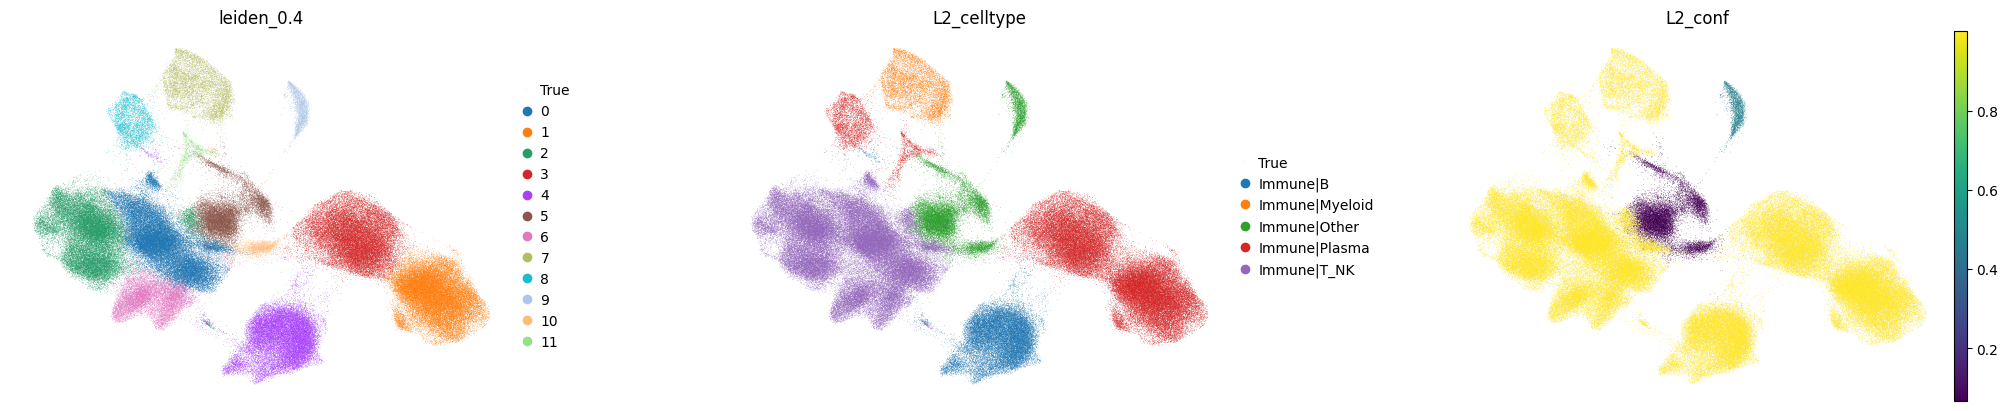

In [28]:
# UMAP（标签/置信度/批次）
sc.pl.umap(sub, color=[main_key,"L2_celltype","L2_conf"],
           frameon=False, wspace=0.3, label=True,)

保存注释结果umap

In [29]:
import os
import matplotlib.pyplot as plt

# 绘制并保存 UMAP 图
fig_path = os.path.join(FIG_DIR, "L2_Immune_annotation_UMAP.png")

sc.pl.umap(
    sub,
    color=["L2_celltype"],
    frameon=False,
    title="L2 Immune Lineage Annotation",  # 英文标题
    save=None,  # 我们手动保存，不用 Scanpy 自动保存
    show=False  # 防止 Notebook 中立即弹出
)

# 手动保存图片（可控格式和分辨率）
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.close()

print(f"[Saved figure] → {fig_path}")


[Saved figure] → /mnt/c/Users/Future/Nutstore/1/UC/scRNA-seq_data/06_annotation/figs/L2_Immune_annotation_UMAP.png


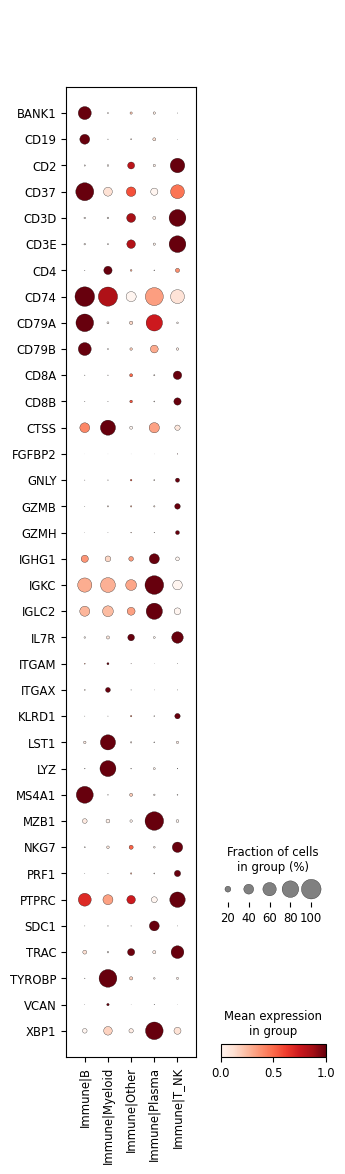

In [30]:
# Dotplot（粗分类核心 marker）
core_markers = sorted({g for v in coarse_panels.values() for g in v})
if core_markers:
    sc.pl.dotplot(sub, var_names=core_markers, groupby="L2_celltype",
                  standard_scale="var", swap_axes=True, dendrogram=False,
                  )

## 保存

In [31]:
wanted_cols = [
    main_key,                 # 簇ID（如 leiden_0.5）
    "GSM", "GSE",             # 可选：批次/来源（若不存在会自动跳过）
    "L2_marker", "L2_marker_gap",
    "L2_score",  "L2_score_gap",
    "L2_gpt_raw", "L2_gpt",
    "L2_celltype_sub",        # 最终子类（回收后已含 Other）
    "L2_conf_methods",        # 方法一致性置信度
    "L2_stability",           # 多分辨率稳定度
    "L2_conf",                # 综合置信度
    "L2_votes"                # 投票来源记录
]
out_cols = [c for c in wanted_cols if c in sub.obs.columns]

sub.obs[out_cols].to_csv(OUT_CSV, index=True)
print(f"[Saved per-cell table] -> {OUT_CSV}")

[Saved per-cell table] -> /mnt/c/Users/Future/Nutstore/1/UC/scRNA-seq_data/06_annotation/L2/01_L2_immune_summary.csv


In [32]:
# 写回全集并保存
adata.obs.loc[sub.obs_names, "L2_celltype"]  = sub.obs["L2_celltype"]
adata.obs.loc[sub.obs_names, "L2_conf"]      = sub.obs["L2_conf"]
adata.obs.loc[sub.obs_names, "L2_votes"]     = sub.obs["L2_votes"]
adata.obs.loc[sub.obs_names, "L2_stability"] = sub.obs["L2_stability"]
adata.write(OUT_H5AD)
print(f"[Done] Immune L2（粗分类）完成：\n- 表: {OUT_CSV}\n- 对象: {OUT_H5AD}")


[Done] Immune L2（粗分类）完成：
- 表: /mnt/c/Users/Future/Nutstore/1/UC/scRNA-seq_data/06_annotation/L2/01_L2_immune_summary.csv
- 对象: /mnt/c/Users/Future/Nutstore/1/UC/scRNA-seq_data/06_annotation/L2/01_L2_immune_annotated.h5ad
